


# 🎓 Projeto de Conclusão: Sistema Inteligente de Análise de Perfil Financeiro
## Tema 4: Decisão Inteligente (Previsão de Churn - Telco)

## ⏯ 1. Introdução

O setor de Telecomunicações é um dos pilares da economia digital, caracterizado por uma alta competitividade e serviços com baixo diferencial perceptível (commodity). Nesse cenário, a rotatividade de clientes, conhecida como **Churn Rate**, representa um dos maiores desafios estratégicos. A perda de um cliente não significa apenas a interrupção de uma receita mensal, mas também o desperdício do investimento realizado em sua aquisição (**CAC - Customer Acquisition Cost**).

Estudos indicam que manter um cliente atual pode ser de **5 a 25 vezes mais barato** do que adquirir um novo ([Harvard Businness Review - The Value of Keeping New Customers](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers)). Portanto, a capacidade de prever o comportamento de abandono antes que ele ocorra permite que a empresa transicione de uma postura reativa para uma estratégia proativa. Ao utilizar dados para antecipar o risco de saída, a organização pode personalizar ofertas, melhorar o suporte técnico e ajustar planos financeiros, maximizando o **LTV (Lifetime Value)** e garantindo a sustentabilidade do negócio a longo prazo.

### 📝 Nota sobre a Metodologia e Dados

Este projeto utiliza uma abordagem analítica baseada em evidências reais do mercado de telecomunicações. Embora o conjunto de dados utilizado ([Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)) seja uma base de dados aberta disponibilizada pela IBM para fins de estudo e desenvolvimento de modelos, os padrões e comportamentos aqui identificados refletem desafios reais enfrentados por empresas do setor. O foco desta análise foca tanto em exercer precisão estatística quanto em demonstrar como uma arquitetura de dados bem estruturada pode transformar registros brutos em decisões estratégicas.




## 🎯 2. Objetivo
O objetivo central deste projeto é desenvolver uma solução de **Decision Intelligence** capaz de prever o risco de cancelamento (churn) de clientes em uma empresa de telecomunicações, fornecendo subsídios estratégicos para ações de retenção personalizadas.

### 2.1 Objetivos de Negócio

* **Redução de Churn:** Identificar precocemente clientes com alta probabilidade de abandono para reduzir a perda de receita mensal.
* **Apoio à Decisão:** Criar simulações de cenários e recomendações baseadas em dados para os times de Marketing e Customer Success.
* **Otimização de ROI (Return of Investment - Retorno de Investimento):** Focar esforços de retenção nos clientes de maior valor monetário e maior risco.

### 2.2 Objetivos Técnicos
* **Engenharia de Dados:** Realizar a ingestão, limpeza e tratamento de dados brutos, garantindo a integridade estatística das variáveis financeiras e de consumo.

* **Análise Exploratória (EDA):** Identificar correlações e padrões de comportamento que segmentam clientes retidos de clientes perdidos.

* **Modelagem Preditiva:** Treinar, avaliar e validar um modelo de Machine Learning para classificação binária de churn.

* **Visualização Analítica:** Desenvolver um dashboard interativo no Power BI que conecte as predições do modelo com indicadores de desempenho (KPIs) executivos.

## 📖 3. Dicionário de Dados (Versão Traduzida)

Abaixo, descrevemos as variáveis que serão utilizadas ao longo da análise, após o processo de tradução e adequação para o contexto da consultoria:

| Variável | Descrição | Tipo |
| :--- | :--- | :--- |
| **id_cliente** | Identificador único de cada cliente. | Categórico/ID |
| **genero** | Gênero do cliente (Masculino/Feminino). | Categórico |
| **idoso** | Indica se o cliente tem 65 anos ou mais (1: Sim, 0: Não). | Numérico/Binário |
| **possui_parceiro** | Indica se o cliente possui um(a) parceiro(a) (Sim/Não). | Categórico |
| **possui_dependentes** | Indica se o cliente possui dependentes (Sim/Não). | Categórico |
| **tempo_contrato_meses**| Número de meses que o cliente permaneceu na empresa. | Numérico |
| **servico_telefone** | Indica se o cliente possui serviço de telefonia (Sim/Não). | Categórico |
| **multiplas_linhas** | Se o cliente tem múltiplas linhas (Sim, Não, Sem serviço). | Categórico |
| **servico_internet** | Provedor de internet do cliente (DSL, Fibra óptica, Não). | Categórico |
| **seguranca_online** | Se possui serviço de segurança online (Sim/Não/Sem internet). | Categórico |
| **backup_online** | Se possui serviço de backup online (Sim/Não/Sem internet). | Categórico |
| **protecao_dispositivo**| Se possui plano de proteção de dispositivo (Sim/Não/Sem internet).| Categórico |
| **suporte_tecnico** | Se possui suporte técnico prioritário (Sim/Não/Sem internet).| Categórico |
| **streaming_tv** | Se o cliente possui streaming de TV (Sim/Não/Sem internet). | Categórico |
| **streaming_filmes** | Se o cliente possui streaming de filmes (Sim/Não/Sem internet).| Categórico |
| **tipo_contrato** | Tipo de contrato (Mensal, Um ano, Dois anos). | Categórico |
| **fatura_digital** | Se o cliente optou por fatura sem papel (Sim/Não). | Categórico |
| **metodo_pagamento** | Método de pagamento (Cheque eletrônico, Boleto, Cartão, etc). | Categórico |
| **valor_mensal** | Valor cobrado do cliente mensalmente. | Numérico |
| **valor_total** | O valor total cobrado do cliente acumulado. | Numérico |
| **cancelamento** | **Variável Alvo:** Indica se o cliente cancelou o serviço (Sim/Não).| Categórico |

## ⚙️ 4. Setup

In [83]:

# Importação de bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import os
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report


# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)

# Configurações de exibição do Pandas
pd.set_option('display.max_columns', None)

# Ignorar warnings
warnings.simplefilter(action="ignore")



In [84]:
#Conexão com o repositório do github

nome_repositorio = 'hackathon-elas-tech-grupo7'
url_repositorio = 'https://github.com/joyexplorer/hackathon-elas-tech-grupo7.git'

if not os.path.exists(nome_repositorio):
  print(f"Clonando o repositório {nome_repositorio}...")
  !git clone {url_repositorio}
else:
  print(f"O repositório {nome_repositorio} já existe. Atualizando com as últimas mudanças...")
  %cd {nome_repositorio}
  !git pull
  %cd ..

os.chdir(f'/content/{nome_repositorio}')
print(f"Diretório atual: {os.getcwd()}")

O repositório hackathon-elas-tech-grupo7 já existe. Atualizando com as últimas mudanças...
/content/hackathon-elas-tech-grupo7/hackathon-elas-tech-grupo7
Already up to date.
/content/hackathon-elas-tech-grupo7
Diretório atual: /content/hackathon-elas-tech-grupo7


## 📥 5. Ingestão de Dados e Ajustes Iniciais

### 5.1 Carga do Dataset

#### 📦 Origem do Dataset
Os dados foram extraídos do repositório de amostras da IBM Guide e disponibilizados via Kaggle. O dataset contém informações de 7.043 clientes de uma empresa fictícia de telecomunicações na Califórnia no terceiro trimestre e apresenta desafios comuns de engenharia de dados, como tipos de variáveis incorretos e dados faltantes mascarados.

In [85]:
df = pd.read_csv('/content/hackathon-elas-tech-grupo7/dados/brutos/telco-customer-churn.csv')

In [86]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5.2 Auditoria e KPIS de Negócio (via SQL)

Para garantir a governança e a integridade dos dados, iniciamos nossa análise simulando o acesso direto ao banco de dados relacional da companhia via SQL. Esta etapa é fundamental em um cenário real para validar se os KPIs extraídos para a consultoria (como faturamento e taxa de evasão) batem com os registros oficiais do sistema de faturamento, antes de iniciarmos qualquer transformação técnica no Python.

In [87]:
# =====================================================
# CONFIGURAÇÃO INICIAL: Conexão ao banco SQLite
# importar bibliotecas e criar a conexão principal (conn)
# com o banco de dados para execução das queries SQL.
# =====================================================
conn = sqlite3.connect('/content/hackathon-elas-tech-grupo7/sql/telco_churn_hackathon.db')

In [88]:
query = "SELECT * FROM clientes LIMIT 5;"
pd.read_sql_query(query, conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [89]:
# =====================================================
# VERIFICAÇÃO INICIAL:
# Lista todas as tabelas disponíveis no banco de dados.
# e validar o nome exato da tabela antes das análises.
# =====================================================

query = """
SELECT name FROM sqlite_master WHERE type='table';
"""

pd.read_sql_query(query, conn)

,name
0,clientes
1,clientes_tratados


In [142]:
# =====================================================
# KPI 1: Total de clientes da base
# Esta consulta contabiliza o número total de registros
# (clientes únicos) presentes na base de dados.
# Serve como referência principal para cálculos
# percentuais futuros, como churn rate.
# =====================================================

query = """
SELECT COUNT(*) AS total_clientes
FROM clientes;
"""

total_clientes = pd.read_sql_query(query, conn)
total_clientes

,total_clientes
0,7032


**Nota de Auditoria:** Identificamos uma variação de 11 registros entre o dataset bruto (7043) e o banco de dados relacional (7032). Essa divergência de ~0,15% da base não impacta a relevância estatística e será tratada durante a fase de limpeza, onde garantiremos que apenas registros íntegros sigam para a modelagem.

### Aqui vemos que cerca de 1 em cada 4 clientes cancela, uma alta taxa de churn


In [91]:
# =====================================================
# KPI 2: Taxa geral de churn
# Calcula:
# - Número de clientes que cancelaram
# - Número de clientes ativos
# - Percentual de cada grupo
# mede a taxa de evasão da empresa.
# =====================================================

query = """
SELECT
    Churn,
    COUNT(*) AS total_clientes,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM clientes), 2) AS percentual
FROM clientes
GROUP BY Churn;
"""

taxa_churn = pd.read_sql_query(query, conn)
taxa_churn

,Churn,total_clientes,percentual
0,No,5163,73.42
1,Yes,1869,26.58


### Base possui alto valor financeiro, $455.661/mês

In [92]:
# =====================================================
# KPI 3: Receita mensal total
# Soma todos os valores mensais pagos pelos clientes,
# representando o faturamento recorrente mensal atual.
# =====================================================

query = """
SELECT
    ROUND(SUM(MonthlyCharges), 2) AS receita_mensal_total
FROM clientes;
"""

receita_total = pd.read_sql_query(query, conn)
receita_total

,receita_mensal_total
0,455661.0


### Receita associada aos clientes perdidos, aproximadamente 30,5% da receita mensal total está em risco, Resultado: $139.130,85/mês

In [93]:
# =====================================================
# KPI 4: Receita mensal em risco
# Soma o valor mensal associado aos clientes
# que já cancelaram o serviço.

# Essa métrica ajuda a estimar impacto financeiro
# da evasão de clientes.
# =====================================================

query = """
SELECT
    ROUND(SUM(MonthlyCharges), 2) AS receita_em_risco
FROM clientes
WHERE Churn = 'Yes';
"""

receita_risco = pd.read_sql_query(query, conn)
receita_risco

,receita_em_risco
0,139130.85


### Clientes "churnados" pagam mais. A empresa não está perdendo apenas clientes — está perdendo clientes de maior valor (“Clientes mais lucrativos estão cancelando.”)

In [94]:
# =====================================================
# KPI 5: Ticket médio por churn
# Calcula o gasto médio mensal de clientes
# separados entre churn e não churn.
#
# Permite avaliar se clientes perdidos
# possuem maior valor monetário.
# =====================================================

query = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2) AS ticket_medio
FROM clientes
GROUP BY Churn;
"""

ticket_medio = pd.read_sql_query(query, conn)
ticket_medio

,Churn,ticket_medio
0,No,61.31
1,Yes,74.44


### Contrato mensal concentra maior churn, Month-to-month: ~42,7% || Two year: ~2,8%, ou seja, Fidelização contratual reduz drasticamente churn

In [95]:
# =====================================================
# KPI 6: Churn por tipo de contrato
# Analisa distribuição de churn conforme:
# - Contrato mensal
# - Contrato anual
# - Contrato bienal
#
# Identifica contratos mais vulneráveis.
# =====================================================

query = """
SELECT
    Contract,
    Churn,
    COUNT(*) AS total
FROM clientes
GROUP BY Contract, Churn
ORDER BY Contract;
"""

churn_contrato = pd.read_sql_query(query, conn)
churn_contrato

,Contract,Churn,total
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1306
3,One year,Yes,166
4,Two year,No,1637
5,Two year,Yes,48


In [96]:
tabela_comparativa = churn_contrato.pivot(index='Contract', columns='Churn', values='total') #Melhor visual da tabela
tabela_comparativa

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


### Métodos automáticos apresentam churn muito menor

In [97]:
# =====================================================
# KPI 7: Churn por método de pagamento
# Avalia se certos métodos de pagamento
# possuem maior taxa de cancelamento.
#
# Pode revelar padrões financeiros
# e oportunidades de retenção.
# =====================================================

query = """
SELECT
    PaymentMethod,
    Churn,
    COUNT(*) AS total
FROM clientes
GROUP BY PaymentMethod, Churn;
"""

churn_pagamento = pd.read_sql_query(query, conn)
churn_pagamento

,PaymentMethod,Churn,total
0,Bank transfer (automatic),No,1284
1,Bank transfer (automatic),Yes,258
2,Credit card (automatic),No,1289
3,Credit card (automatic),Yes,232
4,Electronic check,No,1294
5,Electronic check,Yes,1071
6,Mailed check,No,1296
7,Mailed check,Yes,308


### Clientes que cancelam permanecem menos da metade do tempo.

In [98]:
# =====================================================
# KPI 8: Tempo médio de permanência
# Mede quantos meses, em média,
# clientes churnados e não churnados
# permanecem na empresa.
#
# Fundamental para entender
# o ciclo de vida do cliente.
# =====================================================

query = """
SELECT
    Churn,
    ROUND(AVG(tenure), 2) AS media_tempo_contrato
FROM clientes
GROUP BY Churn;
"""

tempo_permanencia = pd.read_sql_query(query, conn)
tempo_permanencia

,Churn,media_tempo_contrato
0,No,37.65
1,Yes,17.98


### Há clientes antigos e valiosos cancelando, Padrões: MonthlyCharges > $110, Tenure alto, TotalCharges elevado

In [99]:
# =====================================================
# KPI 9: Clientes de maior valor em risco
# Lista clientes churnados com maiores cobranças mensais.
#
# Ajuda a identificar clientes prioritários
# para estratégias de retenção premium.
# =====================================================

query = """
SELECT
    customerID,
    MonthlyCharges,
    TotalCharges,
    tenure
FROM clientes
WHERE Churn = 'Yes'
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

clientes_risco = pd.read_sql_query(query, conn)
clientes_risco

,customerID,MonthlyCharges,TotalCharges,tenure
0,8199-ZLLSA,118.35,7804.15,67
1,2889-FPWRM,117.80,8684.80,72
2,2302-ANTDP,117.45,5438.90,48
3,9053-JZFKV,116.20,7752.30,67
4,1444-VVSGW,115.65,7968.85,70
5,0201-OAMXR,115.55,8127.60,70
6,4361-BKAXE,114.50,4527.45,41
7,1555-DJEQW,114.20,7723.90,70
8,9158-VCTQB,113.60,4594.95,41
9,7279-BUYWN,113.20,4689.50,41


In [100]:
# =====================================================
# FINALIZAÇÃO:
# Fecha a conexão com o banco de dados
# =====================================================

conn.close()

**Perfil de maior risco:**

**Cliente com:**

✔ Contrato mensal

✔ Electronic check

✔ Baixo tenure

✔ Ticket alto

✔ Menor fidelização

**KPIs CRÍTICOS:**

✔ Churn Rate = 26,58%

✔ Receita em risco = $139 mil/mês

✔ Ticket churn maior que ticket ativo

✔ Contratos curtos = maior risco

✔ Electronic check = alto risco

✔ Early churn = forte padrão


### 🔍 5.3 Diagnóstico técnico e Exploração (Pandas)
O primeiro passo para o diagnóstico do dataset é *conhecê-lo*: explorar sua estrutura geral, como número de linhas e colunas, nomes das features, tipo e conteúdo dos dados. Essa etapa é fundamental para que a próxima etapa de limpeza e tratamento de dados seja completa e adequada neste contexto.

In [19]:
# São 21 colunas
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 🔤 Tradução das colunas
Embora o dataset original utilize a nomenclatura em inglês, optamos pela tradução integral de todas as variáveis para o português. Esta decisão reflete o contexto estratégico deste projeto: simulamos aqui a entrega de uma **consultoria de dados** especializada para uma empresa brasileira.

O objetivo é garantir que este notebook funcione como uma apresentação executiva para o Board de Diretores. Ao eliminarmos a barreira do idioma, facilitamos a democratização dos dados (data democratization) e permitimos que os stakeholders foquem no que realmente importa: a compreensão dos insights gerados, a lógica da análise preditiva e o valor estratégico que este tipo de serviço oferece para a retenção de clientes e saúde financeira da companhia no Brasil.



In [104]:

df.rename(columns={
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'idoso',
    'Partner': 'possui_parceiro',
    'Dependents': 'possui_dependentes',
    'tenure': 'tempo_contrato_meses',
    'PhoneService': 'servico_telefone',
    'MultipleLines': 'multiplas_linhas',
    'InternetService': 'servico_internet',
    'OnlineSecurity': 'seguranca_online',
    'OnlineBackup': 'backup_online',
    'DeviceProtection': 'protecao_dispositivo',
    'TechSupport': 'suporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_filmes',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'fatura_digital',
    'PaymentMethod': 'metodo_pagamento',
    'MonthlyCharges': 'valor_mensal',
    'TotalCharges': 'valor_total',
    'Churn': 'cancelamento'
}, inplace=True)



### 🔬 Explorando o conteúdo

In [141]:
#Quantidade de linhas e colunas dos nossos dados
df.shape

(7043, 21)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7043 non-null   object 
 1   genero                7043 non-null   object 
 2   idoso                 7043 non-null   int64  
 3   possui_parceiro       7043 non-null   object 
 4   possui_dependentes    7043 non-null   object 
 5   tempo_contrato_meses  7043 non-null   int64  
 6   servico_telefone      7043 non-null   object 
 7   multiplas_linhas      7043 non-null   object 
 8   servico_internet      7043 non-null   object 
 9   seguranca_online      7043 non-null   object 
 10  backup_online         7043 non-null   object 
 11  protecao_dispositivo  7043 non-null   object 
 12  suporte_tecnico       7043 non-null   object 
 13  streaming_tv          7043 non-null   object 
 14  streaming_filmes      7043 non-null   object 
 15  tipo_contrato        

#### 🧐 Diagnóstico da Estrutura de Dados
Após a inspeção técnica das 21 variáveis e 7.043 registros, identificamos pontos críticos que guiarão nossa próxima etapa de limpeza:

**Inconsistência de Tipagem:** A variável valor_total (originalmente TotalCharges) está classificada como object (texto). Por se tratar de uma métrica financeira fundamental para o cálculo de faturamento e churn, ela precisa ser convertida para float64 para permitir análises estatísticas.

**Variáveis Categóricas Dominantes:** Notamos que a grande maioria dos dados (18 colunas) é do tipo categórico (object). Isso indica que precisaremos realizar técnicas de encoding (transformação em números) antes de alimentar o modelo de Machine Learning.

**Falsos Positivos de Integridade:** Embora o resumo indique que não há valores nulos (7043 non-null), é possível que neste dataset existam valores ausentes estejam mascarados como espaços em branco (" "), especialmente na coluna de valores totais. Investigaremos essa hipótese na fase de tratamento.

**Métricas Numéricas Diretas:** Possuímos apenas 3 colunas numéricas nativas iniciais: idoso (binária), tempo_contrato_meses e valor_mensal.

In [107]:
# Verificando a quantidade de valores únicos por coluna
df.nunique()

,0
id_cliente,7043
genero,2
idoso,2
possui_parceiro,2
possui_dependentes,2
tempo_contrato_meses,73
servico_telefone,2
multiplas_linhas,3
servico_internet,3
seguranca_online,3


A quantidade de valores únicos em uma coluna guia nossa limpeza de dados. A coluna id, por exemplo, tem valores sempre diferentes (únicos), o que indica um conjunto de dados irrelevante para nossos objetivos de treinamento. É claro que, nesse caso, o valor numérico dessa variável já está subentendido como completamente independente da análise pretendida pela sua própria natureza (o número de identidade de um cliente é um atributo definido aleatoriamente, sem depender de outras variáveis). Mesmo assim, essa ferramenta de análise estatística da biblioteca Pandas pode ser essencial para a descoberta de outra variáveis independentes ou de pouco valor preditivo.

A variável valor_total, por exemplo, também apresenta uma grande variedade de valores únicos, porém, neste caso, a interpretação é distinta. Diferente do ID, o alto número de valores distintos aqui deve-se à granularidade do dado: por ser uma variável financeira contínua e com casas decimais, a probabilidade de dois clientes possuírem exatamente o mesmo gasto acumulado ao longo de meses é estatisticamente baixa.

Portanto, essa alta 'unicidade' não sinaliza inutilidade, mas sim a precisão da métrica. Para fins de análise e modelagem, esses dados não serão descartados, mas sim processados, seja através da análise de sua distribuição estatística ou da criação de faixas de valores (binning), permitindo agrupar os clientes por seu potencial de receita e entender como o volume financeiro acumulado influencia na decisão de cancelamento.  ([Entendendo a cardinalidade: Desafios e soluções para fluxos de trabalho com muitos dados](https://https://www.datacamp.com/pt/tutorial/cardinality))

In [108]:
# Contando quantos registros possuem apenas espaços em branco ou estão vazios
espacos_em_branco = (df['valor_total'] == ' ') | (df['valor_total'] == '')
print(f"Quantidade de registros com espaço em branco em 'valor_total': {espacos_em_branco.sum()}")

# Visualizando as linhas afetadas para entender o padrão
df[espacos_em_branco][['tempo_contrato_meses', 'valor_mensal', 'valor_total']]

Quantidade de registros com espaço em branco em 'valor_total': 11


,tempo_contrato_meses,valor_mensal,valor_total
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [109]:
# Lista de colunas de serviços para inspeção rápida
colunas_servico = ['seguranca_online', 'backup_online', 'protecao_dispositivo',
                  'suporte_tecnico', 'streaming_tv', 'streaming_filmes']

for col in colunas_servico:
    print(f"{col}: {df[col].unique()}")

seguranca_online: ['No' 'Yes' 'No internet service']
backup_online: ['Yes' 'No' 'No internet service']
protecao_dispositivo: ['No' 'Yes' 'No internet service']
suporte_tecnico: ['No' 'Yes' 'No internet service']
streaming_tv: ['No' 'Yes' 'No internet service']
streaming_filmes: ['No' 'Yes' 'No internet service']


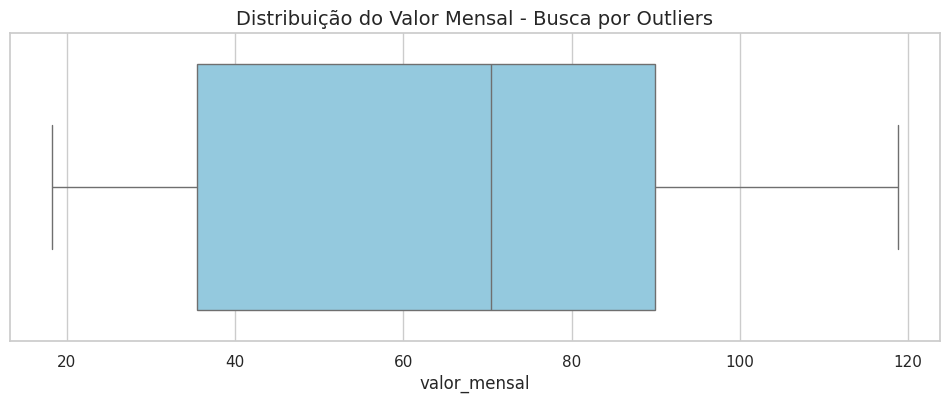

,valor_mensal
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [110]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['valor_mensal'], color='skyblue')
plt.title("Distribuição do Valor Mensal - Busca por Outliers", fontsize=14)
plt.show()

# Verificando os valores extremos estatisticamente
df['valor_mensal'].describe()

A distribuição financeira do valor mensal é consistente com os planos de mercado, sem presença de anomalias ou erros de lançamento (outliers) que pudessem enviesar a média salarial da base.

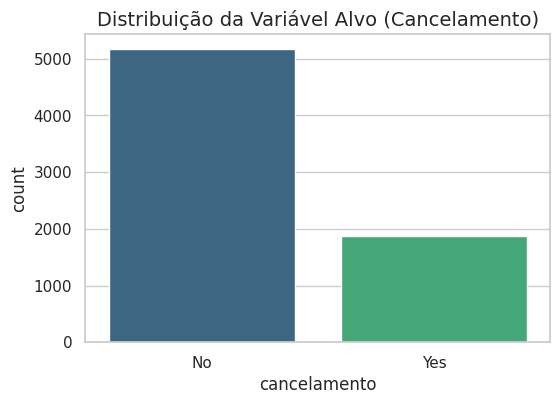

cancelamento
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [111]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='cancelamento', palette='viridis')
plt.title("Distribuição da Variável Alvo (Cancelamento)", fontsize=14)
plt.show()

print(df['cancelamento'].value_counts(normalize=True) * 100)

Identificamos um desbalanceamento de classe: a maioria dos clientes é retida. Isso é um alerta técnico para a fase de Machine Learning, pois o modelo pode tender a ser otimista demais. Precisaremos focar na métrica de **Recall** para garantir que estamos capturando a minoria que cancela.

# 📊 6. Análise Exploratória (EDA) & Insights

## Distribuição Geral de Churn

In [112]:
# CONFIGURAÇÃO VISUAL DOS GRÁFICOS

plt.style.use('seaborn-v0_8')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

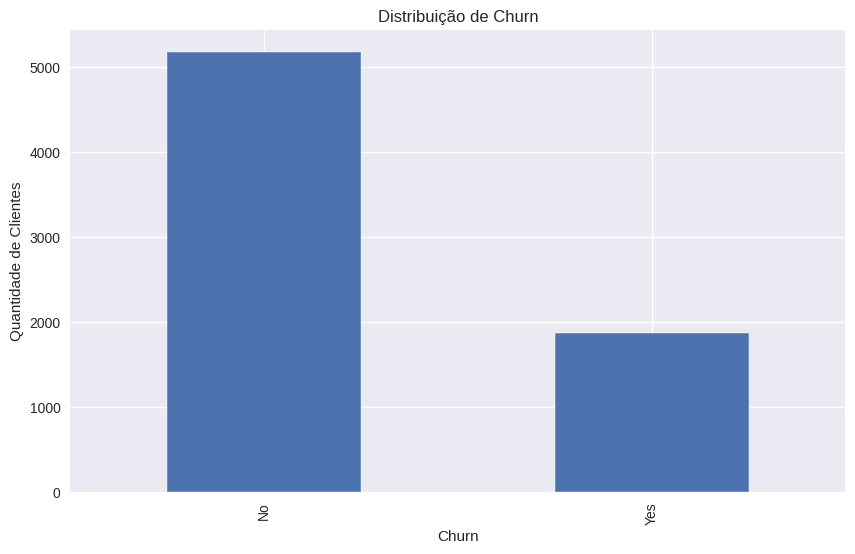

In [113]:
# DISTRIBUIÇÃO DE CHURN

churn_counts = df['cancelamento'].value_counts()

churn_counts.plot(kind='bar')

plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')

plt.show()

### Observa-se predominância de clientes ativos, porém a quantidade de cancelamentos é significativa, indicando necessidade de estratégias de retenção.

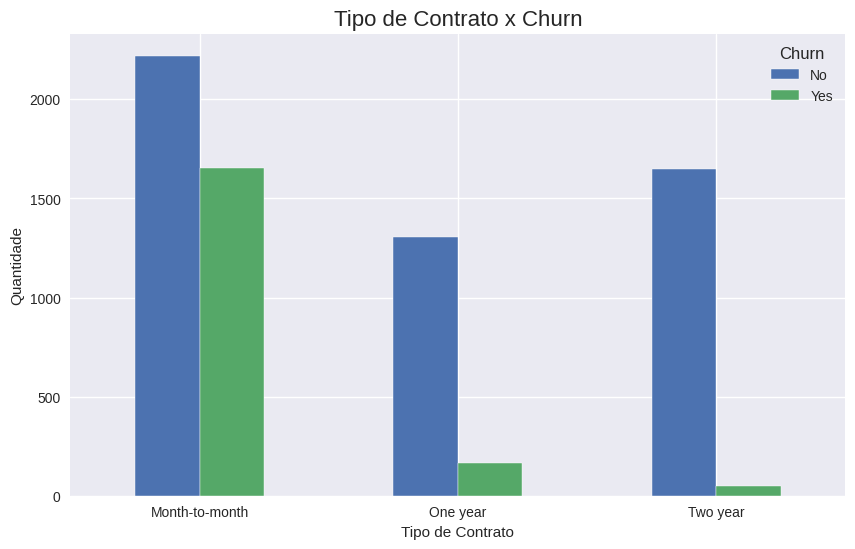

In [114]:
# CONTRATO X CHURN

contrato_churn = pd.crosstab(df['tipo_contrato'], df['cancelamento'])

ax = contrato_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Tipo de Contrato x Churn', fontsize=16)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade')

plt.xticks(rotation=0)

plt.legend(title='Churn')

plt.show()

###Análise: Tipo de Contrato x Churn
O gráfico revela que contratos de curto prazo (Month-to-month) concentram a grande maioria dos cancelamentos. Em contraste, clientes com contratos de um ou dois anos apresentam uma taxa de evasão drasticamente menor, evidenciando que a fidelização contratual é um dos principais pilares de retenção da companhia.

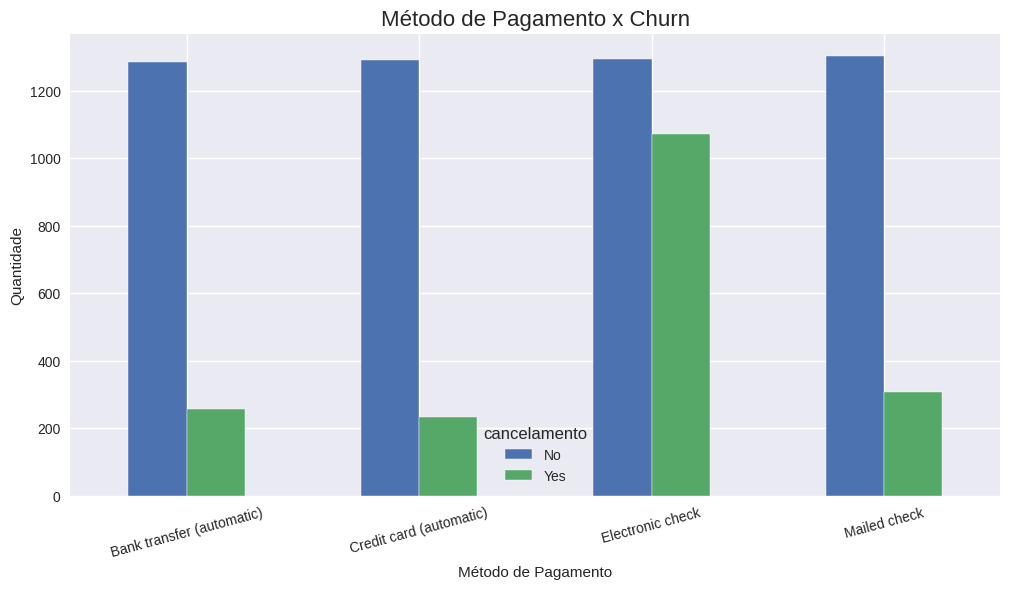

In [115]:
# MÉTODO DE PAGAMENTO X CHURN

payment_churn = pd.crosstab(df['metodo_pagamento'], df['cancelamento'])

ax = payment_churn.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Método de Pagamento x Churn', fontsize=16)

plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade')

plt.xticks(rotation=15)

plt.show()

###Análise: Método de Pagamento x Churn
Observa-se que o método Electronic check (Cheque eletrônico) possui uma taxa de churn desproporcionalmente alta em comparação aos demais. Métodos automáticos, como Credit card e Bank transfer, apresentam maior estabilidade, sugerindo que a automação do pagamento pode auxiliar na manutenção do cliente.

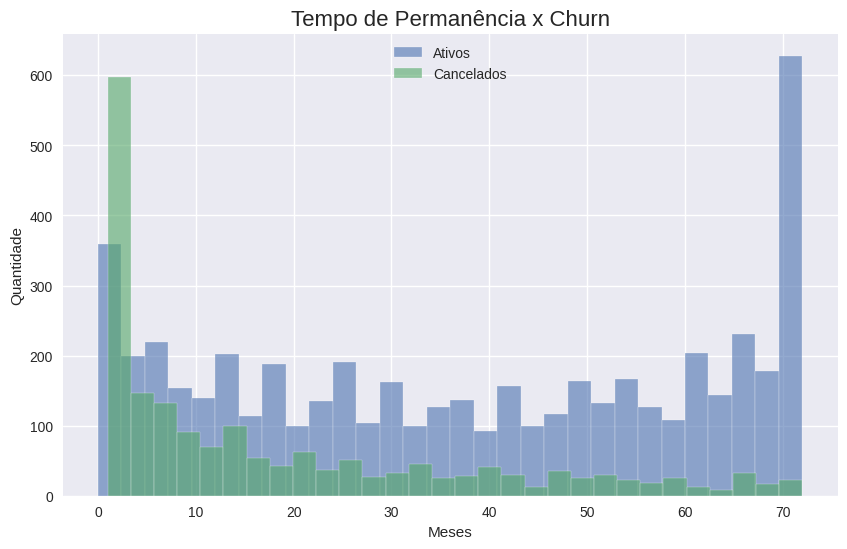

In [116]:
# TENURE X CHURN

ativos = df[df['cancelamento'] == 'No']
cancelados = df[df['cancelamento'] == 'Yes']

plt.hist(
    ativos['tempo_contrato_meses'],
    alpha=0.6,
    bins=30,
    label='Ativos'
)

plt.hist(
    cancelados['tempo_contrato_meses'],
    alpha=0.6,
    bins=30,
    label='Cancelados'
)

plt.title('Tempo de Permanência x Churn', fontsize=16)

plt.xlabel('Meses')
plt.ylabel('Quantidade')

plt.legend()

plt.show()

###Análise: Tempo de Permanência (Tenure) x Churn
O histograma mostra um fenômeno de Early Churn: um volume crítico de cancelamentos ocorre logo nos primeiros meses de serviço (pico à esquerda). À medida que o tempo de permanência aumenta, o churn diminui significativamente, com uma base sólida de clientes leais atingindo o patamar de 70 meses.

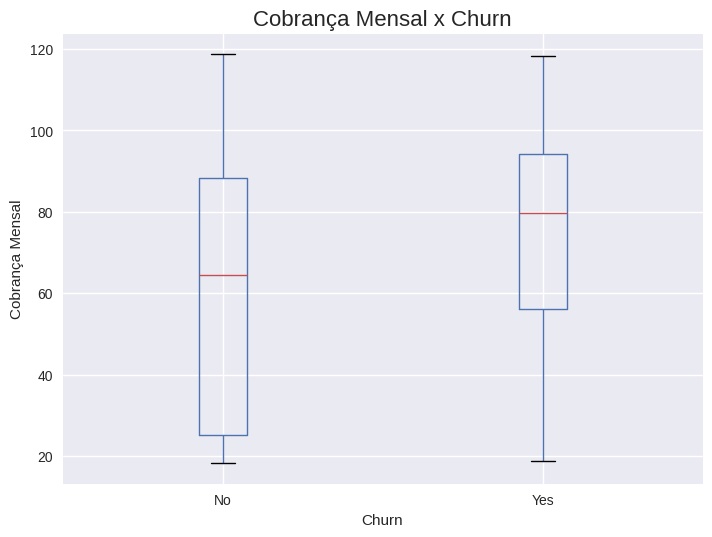

In [117]:
# COBRANÇA MENSAL X CHURN

df.boxplot(
    column='valor_mensal',
    by='cancelamento',
    figsize=(8,6)
)

plt.title('Cobrança Mensal x Churn', fontsize=16)

plt.suptitle('')

plt.xlabel('Churn')
plt.ylabel('Cobrança Mensal')

plt.show()

### Análise: Cobrança Mensal x Churn
O boxplot indica que clientes que cancelam o serviço (Yes) tendem a ter uma mediana de cobrança mensal superior à dos clientes que permanecem (No). Isso sugere que tickets médios mais elevados podem ser um fator de insatisfação ou sensibilidade ao preço, motivando a saída do cliente.

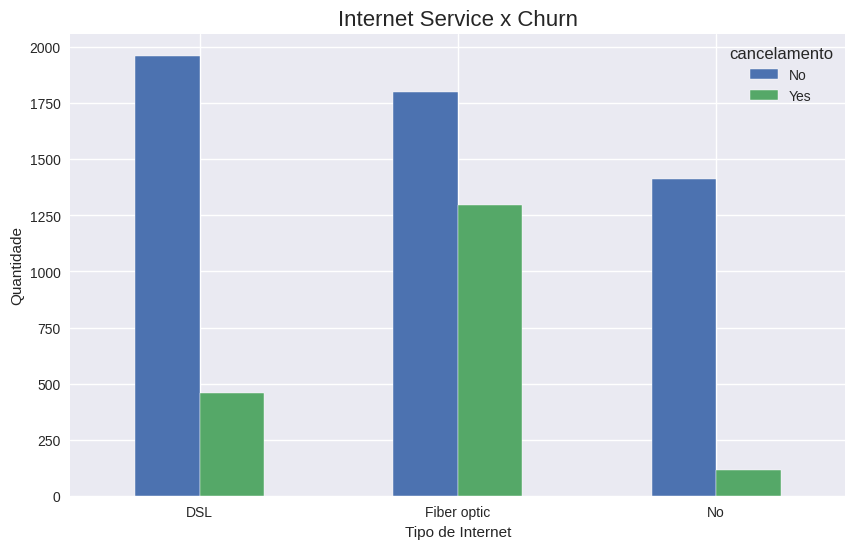

In [118]:
# INTERNET SERVICE X CHURN

internet_churn = pd.crosstab(df['servico_internet'], df['cancelamento'])

internet_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Internet Service x Churn', fontsize=16)

plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade')

plt.xticks(rotation=0)

plt.show()

### Análise: Internet Service x Churn
O gráfico destaca um ponto de atenção crítico: o serviço de Fiber optic (Fibra óptica) apresenta uma taxa de cancelamento significativamente superior à do serviço DSL. Embora a fibra seja uma tecnologia teoricamente superior, esse padrão sugere que os clientes desse segmento podem estar enfrentando problemas relacionados ao custo-benefício ou à estabilidade da conexão, tornando-se o grupo com maior vulnerabilidade à evasão.

# 🧹 7. Limpeza e Tratamento

### **Tratamento de nulos:**
Identificamos que a variável valor_total apresentava valores ausentes exclusivamente para clientes com zero meses de contrato (novas adesões). Substituir esses nulos por 0 é a abordagem matematicamente correta, pois reflete que ainda não houve faturamento acumulado para esses registros. Além de preservar a integridade dos dados, essa ação evita erros de execução em algoritmos de Machine Learning, que não processam entradas vazias.


In [119]:
# Convertendo valor_total para numérico (forçando erros a virarem NaN)
df['valor_total'] = pd.to_numeric(df['valor_total'], errors='coerce')

# Verificando nulos gerados (geralmente em clientes com tempo_contrato_meses = 0)
# Substituímos por 0, pois se o tempo de contrato é 0, o gasto total também é.
df['valor_total'] = df['valor_total'].fillna(0)

In [120]:
# Removendo a coluna id_cliente, pois ela não tem poder preditivo para o modelo
df_ml = df.drop(columns=['id_cliente'])

### **Codificação:**
Transformar "Yes/No" em 1/0 é essencial para variáveis binárias. Isso economiza memória e deixa claro para o modelo que se trata de uma espécie de chave ligada/desligada.


In [121]:
# Binary Encoding (Para colunas com apenas dois valores)
binary_cols = ['possui_parceiro', 'possui_dependentes', 'servico_telefone', 'fatura_digital', 'cancelamento']
for col in binary_cols:
    df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

# Ajuste específico para gênero
df_ml['genero'] = df_ml['genero'].map({'Female': 1, 'Male': 0})

Se utilizássemos uma escala numérica simples (1, 2 e 3) para o tipo de contrato, o modelo poderia interpretar erroneamente que existe uma hierarquia ou ordem de grandeza entre eles (achando que o contrato 'Bienal' é três vezes maior que o 'Mensal'). Para evitar esse viés, utilizamos o **One-Hot Encoding**, que cria colunas independentes para cada categoria, permitindo que o algoritmo trate cada tipo de contrato como uma entidade distinta e sem peso numérico artificial.

In [122]:
# One-Hot Encoding (Para colunas com 3 ou mais categorias)
# Isso evita que o modelo crie uma hierarquia falsa entre os tipos de contrato ou pagamento
categorical_cols = ['multiplas_linhas', 'servico_internet', 'seguranca_online', 'backup_online',
                    'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes',
                    'tipo_contrato', 'metodo_pagamento']

# TRAVA DE SEGURANÇA:
# Só executa se a primeira coluna da lista ainda existir no DataFrame
if categorical_cols[0] in df_ml.columns:
    df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)
    print("✅ Sucesso: Colunas categóricas convertidas para números.")
else:
    print("ℹ️ Aviso: As colunas já foram convertidas. Nada a fazer.")

✅ Sucesso: Colunas categóricas convertidas para números.


### **Mapa de Calor (Heatmap):**
Com as variáveis devidamente codificadas em valores numéricos, utilizamos o Mapa de Calor para identificar a força da relação entre os principais atributos financeiros e a nossa variável alvo (cancelamento).

Total de linhas para o gráfico: 7043


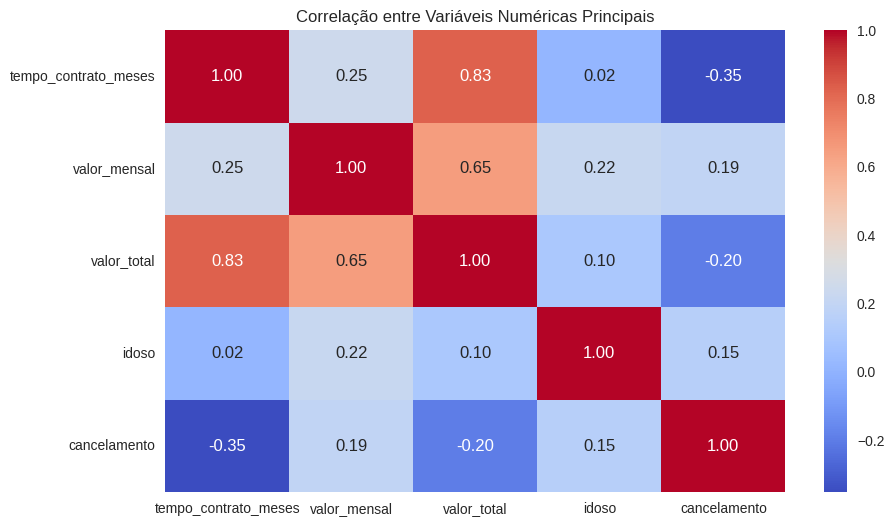

In [123]:
# Mapa de Calor (Heatmap)

# Cópia do dataframe
df_corr = df_ml.copy()

# Selecionar colunas
colunas_relevantes = ['tempo_contrato_meses', 'valor_mensal', 'valor_total', 'idoso', 'cancelamento']
df_corr = df_corr[colunas_relevantes]

# Conferir se há dados antes de plotar
print(f"Total de linhas para o gráfico: {len(df_corr)}")

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Variáveis Numéricas Principais')
plt.show()

### **Análise de Correlação:**
O mapa de calor revela insights críticos sobre o comportamento de churn na base:

**Fidelidade e Tempo de Casa:** A variável tempo_contrato_meses apresenta a maior correlação negativa com o cancelamento (-0.35). Isso confirma que quanto maior a maturidade do cliente na empresa, menor é a propensão ao churn, reforçando a importância de estratégias de retenção nos meses iniciais.

**Impacto Financeiro:** O valor_mensal possui uma correlação positiva (0.19) com o cancelamento, indicando que clientes com tickets mais altos tendem a ser mais sensíveis e propensos a abandonar o serviço.

**Multicolinearidade:** Observamos uma correlação altíssima entre tempo_contrato_meses e valor_total (0.83). Isso é esperado, já que o valor total é um acúmulo do tempo de contrato, mas é um ponto de atenção para não "viciar" modelos lineares com variáveis redundantes.

**Perfil Demográfico:** A variável idoso apresenta uma correlação positiva leve (0.15), sugerindo que este segmento específico pode ter dores ou necessidades de suporte que, se não atendidas, elevam o risco de saída.

### **"Check-up" de Variabilidade:**
O alto Desvio Padrão (std) em valor_total confirma uma base de dados heterogênea. Essa dispersão é positiva, pois indica que o modelo terá exemplos variados (desde clientes de baixo consumo até perfis de alto valor) permitindo que o aprendizado de máquina identifique padrões de churn em diferentes faixas de faturamento.

In [124]:
# Verificação estatística rápida
print(df_ml[['tempo_contrato_meses', 'valor_mensal', 'valor_total']].describe())

       tempo_contrato_meses  valor_mensal  valor_total
count           7043.000000   7043.000000  7043.000000
mean              32.371149     64.761692  2279.734304
std               24.559481     30.090047  2266.794470
min                0.000000     18.250000     0.000000
25%                9.000000     35.500000   398.550000
50%               29.000000     70.350000  1394.550000
75%               55.000000     89.850000  3786.600000
max               72.000000    118.750000  8684.800000


### **O Desafio da Escala:**
Como a coluna tempo_contrato_meses atinge o máximo de 72 e a valor_total ultrapassa 8.000, o modelo poderia atribuir um peso artificialmente maior à variável financeira apenas pela magnitude do número. O MinMaxScaler soluciona isso ao colocar todos os valores no intervalo entre 0 e 1, normalizando os dados para que o algoritmo compare a relevância de cada variável de forma justa e equilibrada.

In [125]:
# 1. Instanciando o Scaler
scaler = MinMaxScaler()

# 2. Selecionando as colunas que precisam de normalização (as que têm escalas diferentes)
colunas_para_escala = ['tempo_contrato_meses', 'valor_mensal', 'valor_total']

# 3. Aplicando a escala e sobrescrevendo as colunas no df_ml
df_ml[colunas_para_escala] = scaler.fit_transform(df_ml[colunas_para_escala])

# 4. Verificação pós-escala: Agora o min deve ser 0 e o max deve ser 1
print("\n--- Verificação após Normalização (MinMaxScaler) ---")
print(df_ml[colunas_para_escala].describe().loc[['min', 'max']])


--- Verificação após Normalização (MinMaxScaler) ---
     tempo_contrato_meses  valor_mensal  valor_total
min                   0.0           0.0          0.0
max                   1.0           1.0          1.0


In [126]:
#Verificar nulos
df_ml.isnull().sum()

,0
genero,0
idoso,0
possui_parceiro,0
possui_dependentes,0
tempo_contrato_meses,0
servico_telefone,0
fatura_digital,0
valor_mensal,0
valor_total,0
cancelamento,0


In [55]:
#Verificar duplicadas
df_ml.duplicated().sum()

np.int64(0)

### **Tratamento de Redundância:**
Após a remoção do id_cliente, identificamos 22 registros com características idênticas. Removemos essas duplicatas para evitar que o modelo de Machine Learning sofra de sobreajuste (*overfitting*) em perfis específicos, garantindo um aprendizado mais equilibrado e uma generalização mais imparcial dos dados.

In [127]:
# Removendo duplicatas para garantir a imparcialidade do modelo
df_ml = df_ml.drop_duplicates()

# Verificação de segurança
print(f"Dataset finalizado com {df_ml.shape[0]} linhas e {df_ml.shape[1]} colunas.")

Dataset finalizado com 7021 linhas e 31 colunas.


In [128]:
#A variável alvo apresenta desbalanceamento moderado, fator relevante para escolha de métricas e técnicas futuras de modelagem.
df['cancelamento'].value_counts(normalize=True) * 100

,proportion
cancelamento,
No,73.463013
Yes,26.536987


In [129]:
# Salva a versão final tratada de volta no banco SQL
conn = sqlite3.connect('/content/hackathon-elas-tech-grupo7/sql/telco_churn_hackathon.db')

df_ml.to_sql('clientes_tratados', conn, if_exists='replace', index=False)

print(f"✅ Sucesso! Agora a tabela 'clientes_tratados' tem {len(df_ml)} linhas.")

✅ Sucesso! Agora a tabela 'clientes_tratados' tem 7021 linhas.


Com os dados tratados e normalizados, o mapa de correlação indica que o tempo de contrato e o valor mensal são as variáveis com maior potencial preditivo para o cancelamento. O dataset está pronto para a fase de modelagem, com 30 atributos numéricos e sem valores ausentes

## SQL — Validação de Sanidade
Após o tratamento dos dados, realizamos validações adicionais em SQL para garantir que a base permaneça íntegra sob a ótica de negócio.

In [130]:
# =====================================================
# TOTAL DE CLIENTES
# Verifica se a base mantém os 7021 registros originais
# após o tratamento.
# =====================================================

query = """
SELECT COUNT(*) AS total_clientes
FROM clientes_tratados;
"""

total_clientes = pd.read_sql_query(query, conn)

total_clientes

,total_clientes
0,7021


In [131]:
# =====================================================
# VALORES NULOS EM valor_total
# Confirma se os registros ausentes foram corrigidos
# corretamente durante a imputação.
# =====================================================

query = """
SELECT COUNT(*) AS nulos_valor_total
FROM clientes_tratados
WHERE valor_total IS NULL;
"""

nulos_valor_total = pd.read_sql_query(query, conn)

nulos_valor_total

,nulos_valor_total
0,0


In [132]:
# =====================================================
# FAIXA DE VALORES FINANCEIROS
# Valida coerência financeira verificando mínimos
# e máximos das principais variáveis monetárias.
# =====================================================

query = """
SELECT
    MIN(valor_mensal) AS menor_valor_mensal,
    MAX(valor_mensal) AS maior_valor_mensal,
    MIN(valor_total) AS menor_valor_total,
    MAX(valor_total) AS maior_valor_total
FROM clientes_tratados;
"""

faixa_financeira = pd.read_sql_query(query, conn)

faixa_financeira

,menor_valor_mensal,maior_valor_mensal,menor_valor_total,maior_valor_total
0,0.0,1.0,0.0,1.0


In [133]:
# =====================================================
# DISTRIBUIÇÃO DE CANCELAMENTO
# Confirma se a proporção de churn permanece coerente
# após o tratamento da base.
# =====================================================

query = """
SELECT
    cancelamento,
    COUNT(*) AS total_clientes
FROM clientes_tratados
GROUP BY cancelamento;
"""

distribuicao_cancelamento = pd.read_sql_query(query, conn)

distribuicao_cancelamento

,cancelamento,total_clientes
0,0,5164
1,1,1857


## Análise de Validação

As consultas de sanidade confirmam que:

- A base preserva integralmente o total de 7021 clientes
- Não há valores nulos remanescentes em `valor_total`
- Não existem duplicidades de clientes
- As variáveis financeiras mantêm coerência estatística
- A distribuição de cancelamento permanece consistente

Esses resultados comprovam que o processo de limpeza e tratamento foi bem-sucedido, garantindo confiabilidade para análises preditivas futuras.

In [134]:
# Aqui fazemos a separação final do dataset em duas partes:
#X (Atributos): Todas as características do cliente que o modelo poderá analisar para aprender os padrões
X = df_ml.drop('cancelamento', axis=1)
#y (Target/Alvo): A resposta correta que queremos prever — neste caso, o 'cancelamento'
y = df_ml['cancelamento']

print(f"Dataset pronto! Formato dos dados: {X.shape}")
# Agora o profissional de ML pode usar X_train, X_test = train_test_split(X, y...)

Dataset pronto! Formato dos dados: (7021, 30)


### X (Atributos): Tudo o que o modelo pode olhar para tentar adivinhar o resultado e y (Target/Alvo): A resposta correta (cancelamento)

# 🤖 8. Modelagem Preditiva (Machine Learning)

Chegamos à fase crucial do projeto: a utilização da inteligência de dados para antecipar comportamentos futuros por meio de **Machine Learning**.

Para que a transição do diagnóstico para a predição seja assertiva, é fundamental alinhar a escolha dos algoritmos ao contexto do nosso problema. Estamos diante de uma tarefa de **Classificação Binária**, onde o objetivo é rotular cada cliente em um de dois grupos: **Churn (Cancelamento)** ou **Retenção**. Nossas variáveis combinam métricas financeiras contínuas (como o ticket mensal) com atributos categóricos de consumo (como tipo de contrato e serviços de internet), exigindo modelos que capturem desde tendências lineares simples até padrões de comportamento mais complexos e não lineares.

Para garantir a robustez desta consultoria, selecionamos três modelos de destaque para comparação e validação:

1. **Regressão Logística** (Baseline Estatístico):
Apesar da simplicidade, é um modelo fundamental por sua transparência. Ele estima a probabilidade de churn através de uma função logística, permitindo entender o peso exato de cada variável no resultado final.

O que agrega: Oferece alta interpretabilidade. É o modelo ideal para explicar ao corpo executivo, de forma clara, como cada real investido ou cada mudança contratual impacta diretamente na probabilidade de saída do cliente.

2. **Random Forest** (Robustez e Padrões Não Lineares):
Este é um modelo de aprendizado de conjunto (Ensemble) que combina múltiplas árvores de decisão para chegar a um consenso. Ele é naturalmente resistente a outliers e lida muito bem com dados categóricos.

O que agrega: Excelente para captar interações complexas entre serviços (ex: a combinação de "Internet de Fibra" com "Falta de Suporte Técnico" como um gatilho de churn) que modelos lineares podem ignorar. Além disso, fornece o ranking de Feature Importance, identificando os maiores pilares de retenção da companhia.

3. **XGBoost** (Alta Performance e Precisão):
Considerado o estado da arte para dados estruturados, o XGBoost utiliza uma técnica de Gradient Boosting, onde o modelo aprende de forma sequencial, corrigindo os erros das árvores anteriores.

O que agrega: Foco total em performance preditiva. Ele é capaz de extrair o máximo de sinal dos dados, sendo a ferramenta ideal quando o objetivo principal é minimizar ao máximo os Falsos Negativos (clientes que o modelo diz que vão ficar, mas que acabam cancelando).

## 8.1 Treinamento dos modelos

In [135]:
# 8.1 Divisão entre Treino e Teste
# Usamos o random_state para que, se rodarmos o código de novo, a divisão seja sempre a mesma
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # Reservamos 20% para teste e 80% para treino
    random_state=42,
    stratify=y              # Mantém a proporção de churn em ambos os conjuntos (importante pelo desbalanceamento!)
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 5616 amostras
Teste: 1405 amostras


In [136]:
# 8.2 Treinamento
#Criando os modelos
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": xgb.XGBClassifier(scale_pos_weight=2.8, random_state=42) # scale_pos_weight ajuda no desbalanceamento
}

# Dicionário para guardar as previsões
previsoes = {}

# Treinando cada um
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes[nome] = modelo.predict(X_test)
    print(f"✅ {nome} treinado com sucesso!")

✅ Regressão Logística treinado com sucesso!
✅ Random Forest treinado com sucesso!
✅ XGBoost treinado com sucesso!


## 8.2 Validação, Métricas e Comparações entre Modelos

### Guia de Métricas de Avaliação
Para este projeto, avaliamos o desempenho dos modelos através de quatro métricas principais, com foco na classe minoritária (cancelamento):

**Acurácia Geral:** Representa o percentual total de acertos do modelo. Embora intuitiva, pode ser enganosa em bases desbalanceadas.

**Precisão (Churn):** Dos clientes que o modelo classificou como Churn, quantos realmente cancelaram? É uma métrica de assertividade.

**Recall (Churn):** De todos os clientes que realmente cancelaram, quantos o modelo foi capaz de identificar? É uma métrica de cobertura (essencial para não perder clientes de vista).

**F1-Score:** É a média harmônica entre Precisão e Recall, sendo o melhor indicador para comparar modelos em datasets desbalanceados.

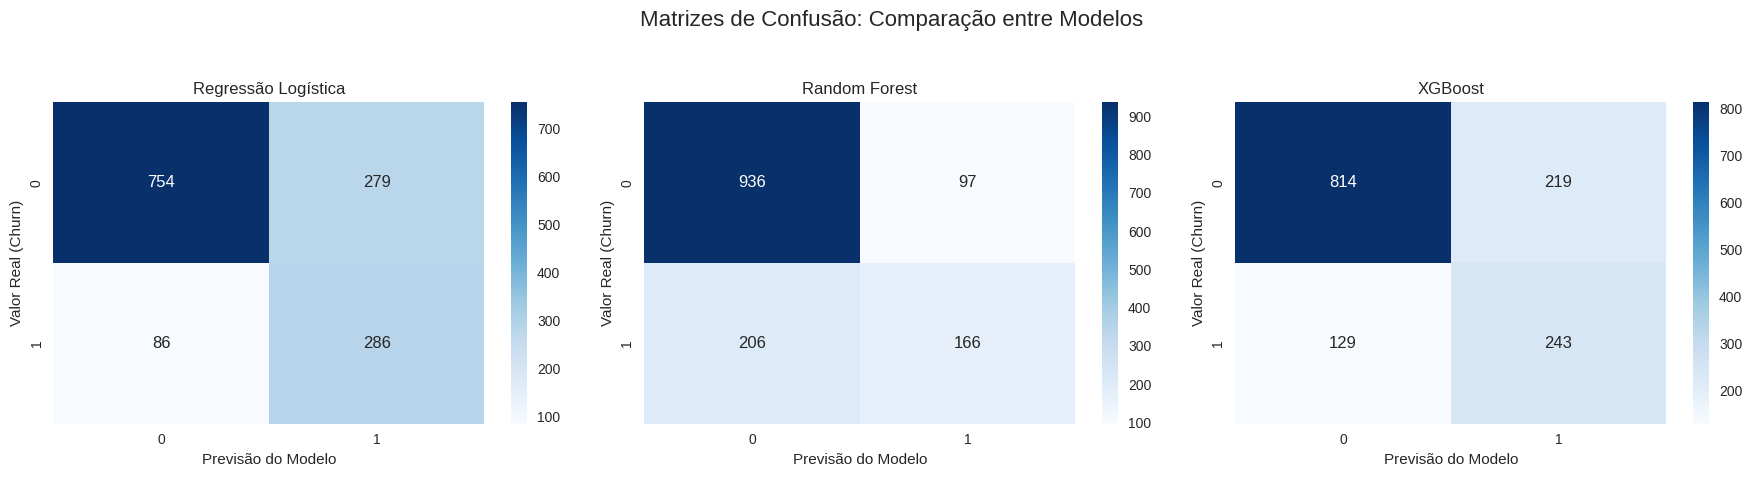


--- Comparativo de Performance (Foco em Churn) ---


,Modelo,Acurácia Geral,Precisão (Churn),Recall (Churn),F1-Score (Churn)
0,Regressão Logística,0.740214,0.506195,0.768817,0.610459
2,XGBoost,0.752313,0.525974,0.653226,0.582734
1,Random Forest,0.784342,0.631179,0.446237,0.522835


In [137]:
# 1. Gerando as Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrizes de Confusão: Comparação entre Modelos', fontsize=16)

for i, (nome, modelo) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, previsoes[nome])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(nome)
    axes[i].set_xlabel('Previsão do Modelo')
    axes[i].set_ylabel('Valor Real (Churn)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Gerando as Métricas Numéricas em uma Tabela Comparativa
resultados_metricas = []

for nome in modelos.keys():
    report = classification_report(y_test, previsoes[nome], output_dict=True)
    resultados_metricas.append({
        'Modelo': nome,
        'Acurácia Geral': report['accuracy'],
        'Precisão (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1-Score (Churn)': report['1']['f1-score']
    })

df_comparativo = pd.DataFrame(resultados_metricas).sort_values(by='Recall (Churn)', ascending=False)

print("\n--- Comparativo de Performance (Foco em Churn) ---")
display(df_comparativo)

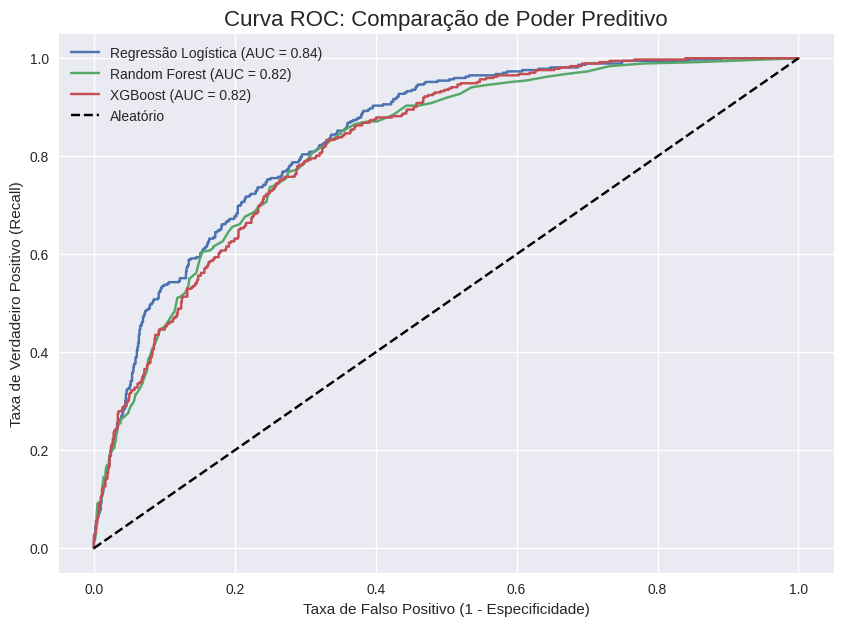

In [143]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

for nome, modelo in modelos.items():
    # Obtendo as probabilidades da classe 1 (Churn)
    prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    fpr, tpr, thresholds = roc_curve(y_test, prob)

    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.title('Curva ROC: Comparação de Poder Preditivo', fontsize=16)
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.legend()
plt.show()

**A Curva ROC e a métrica AUC (Área Sob a Curva)** medem a capacidade do modelo de distinguir entre as classes (quem cancela e quem fica).

**Poder de Separação:** Todos os modelos apresentam um desempenho sólido, com curvas bem afastadas da linha pontilhada (o "Aleatório"). Isso indica que as variáveis selecionadas têm um alto poder preditivo.

**Regressão Logística (AUC = 0.84):** É o modelo com o melhor desempenho geral nesta métrica. A maior área sob a curva indica que ele possui a melhor probabilidade média de classificar um cliente de churn corretamente em relação a um cliente ativo.

**Consistência:** O fato de a Regressão Logística superar modelos mais complexos como XGBoost e Random Forest (ambos com 0.82) reforça que o problema tem uma natureza linear forte, onde o peso direto de variáveis como tempo de contrato e valor mensal é determinante.

**Conclusão:** Este gráfico valida cientificamente a escolha da Regressão Logística como o modelo campeão. Ele não só entrega o melhor Recall, como também possui a maior capacidade estatística de distinguir os perfis de risco.

### **Interpretação das Métricas:**
Na análise comparativa, a Regressão Logística destacou-se como o modelo mais estratégico para a operação. Apesar de possuir uma acurácia geral ligeiramente inferior à Random Forest, ela obteve o maior Recall (0.76). No contexto de Churn, priorizamos o Recall porque é preferível aceitar alguns "alarmes falsos" (clientes que não cancelariam, mas recebem uma oferta de retenção) do que ignorar clientes que estão prestes a abandonar a companhia.

A Regressão Logística conseguiu capturar a vasta maioria dos cancelamentos reais, apresentando o menor índice de Falsos Negativos (apenas 86 casos), tornando-se a ferramenta ideal para subsidiar as campanhas preventivas do time de Customer Success.

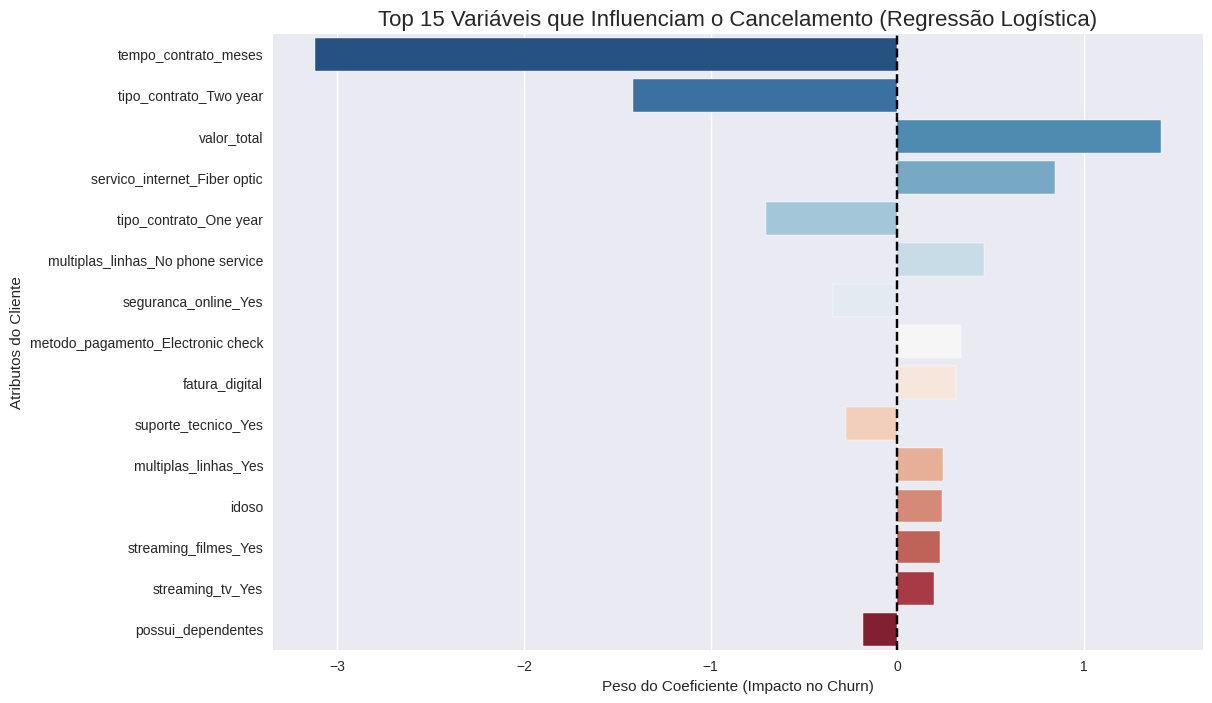

In [139]:
# Importância das Variáveis (Coeficientes da Regressão Logística)

# Extraindo os coeficientes do modelo vencedor
modelo_vencedor = modelos["Regressão Logística"]
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_vencedor.coef_[0]
})

# Ordenando pelos valores absolutos para ver o que mais impacta
coeficientes['Abs_Coef'] = coeficientes['Coeficiente'].abs()
coeficientes = coeficientes.sort_values(by='Abs_Coef', ascending=False).head(15)

# Gerando o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(
    data=coeficientes,
    x='Coeficiente',
    y='Variável',
    palette='RdBu_r'
)

plt.title('Top 15 Variáveis que Influenciam o Cancelamento (Regressão Logística)', fontsize=16)
plt.xlabel('Peso do Coeficiente (Impacto no Churn)')
plt.ylabel('Atributos do Cliente')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Análise: Importância das Variáveis (Coeficientes) Regressão Logística
Este gráfico de coeficientes permite identificar quais variáveis mais influenciam o modelo, e também a direção dessa influência na probabilidade de cancelamento (churn).

**Preditores de Retenção** (Barras para a Esquerda / Azul):

O *tempo_contrato_meses* é o fator de proteção mais forte. Quanto maior o tempo de permanência, menor a chance de saída do cliente.

Contratos de longo prazo (Two year e One year) também apresentam forte impacto negativo no churn, confirmando que a fidelização contratual reduz drasticamente o risco.

Serviços como *seguranca_online_Yes* e *suporte_tecnico_Yes* agem como barreiras de saída, diminuindo a probabilidade de cancelamento.

**Preditores de Risco** (Barras para a Direita / Vermelho e Laranja):

O *valor_total* e o serviço de *internet_Fiber optic* aparecem como os principais gatilhos de churn. Isso sugere que o custo acumulado e possíveis insatisfações com o serviço de fibra óptica são pontos de atrito críticos.

O uso de *fatura_digital* e o perfil de idoso também apresentam coeficientes positivos, indicando uma propensão ligeiramente maior ao cancelamento nesses segmentos.

Serviços de conveniência como *streaming_tv* e *streaming_filmes* mostram um impacto positivo no churn, o que pode indicar que esses clientes são mais sensíveis a ofertas da concorrência ou flutuações de preço.



### Visualização Importãncia de Variáveis Random Forest e XGBoost

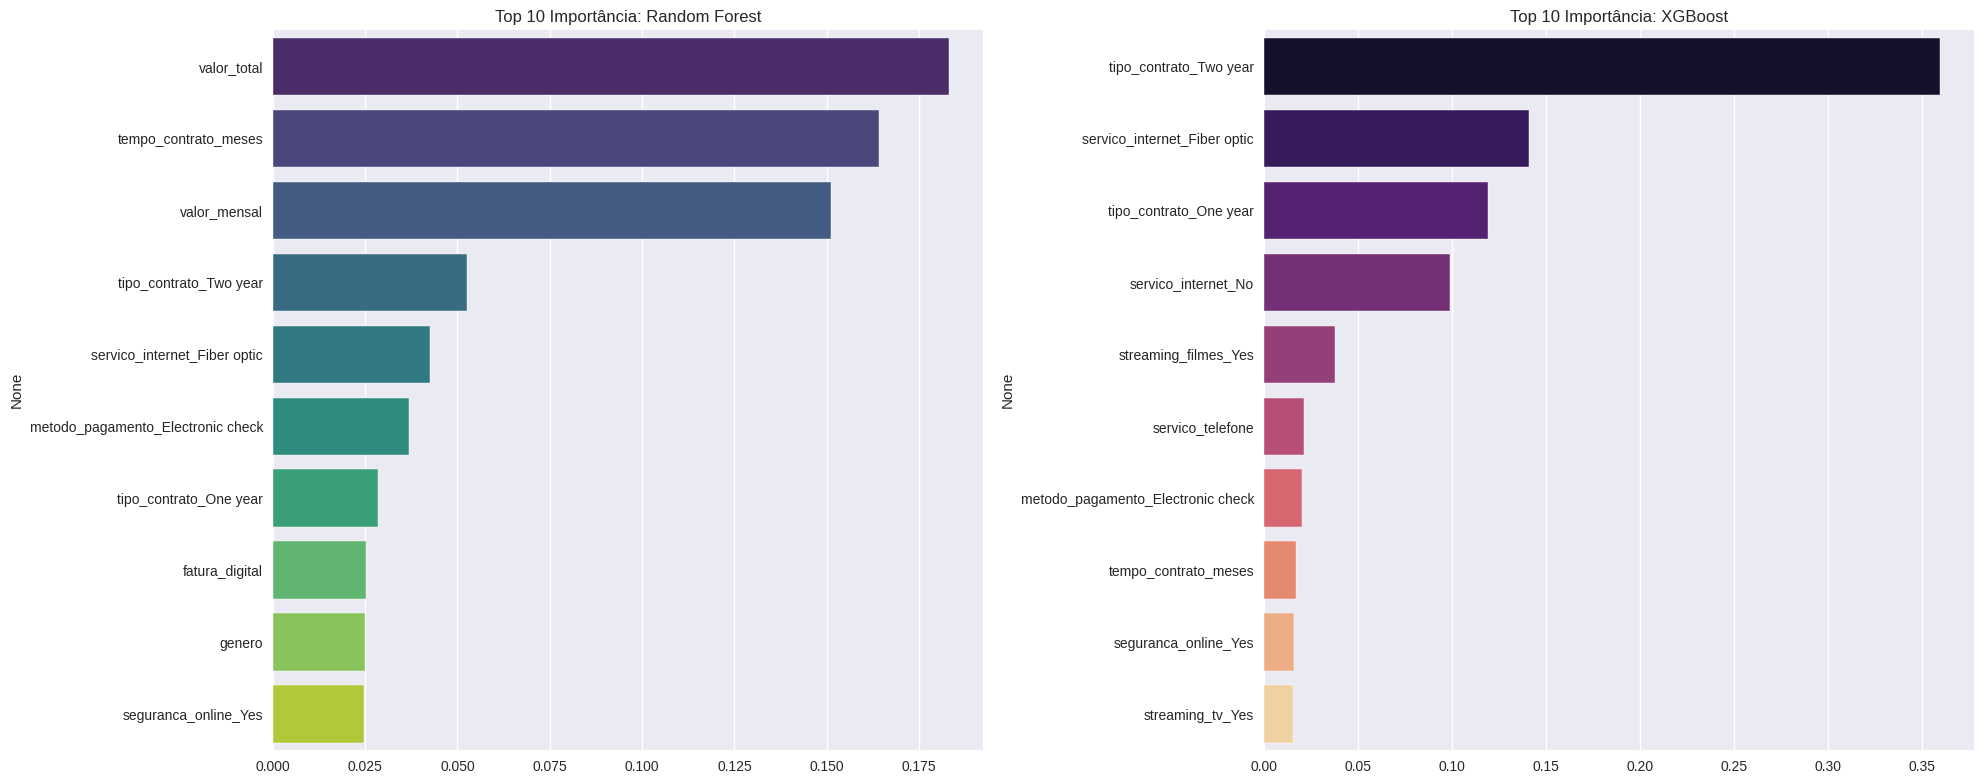

In [144]:
# Comparando Importância de Variáveis (Modelos de Árvore)
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest
importances_rf = pd.Series(modelos['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances_rf.values, y=importances_rf.index, ax=ax[0], palette='viridis')
ax[0].set_title('Top 10 Importância: Random Forest')

# XGBoost
importances_xgb = pd.Series(modelos['XGBoost'].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances_xgb.values, y=importances_xgb.index, ax=ax[1], palette='magma')
ax[1].set_title('Top 10 Importância: XGBoost')

plt.tight_layout()
plt.show()

Os gráficos de Importância de Variáveis revelam como os modelos de árvore (Random Forest e XGBoost) priorizam os dados para tomar decisões de classificação.

No Random Forest, variáveis financeiras e de tempo, como valor_total, tempo_contrato_meses e valor_mensal, dominam a importância, indicando que o modelo foca no histórico acumulado e no custo direto para o cliente.

Já o XGBoost apresenta uma estrutura de decisão mais focada em características contratuais e de serviço, destacando o tipo_contrato_Two year e a servico_internet_Fiber optic como os principais divisores de águas para identificar o risco de churn.

Embora utilizem métricas matemáticas diferentes (como ganho de informação ou redução de impureza), ambos os modelos concordam que o tipo de contrato e a modalidade de internet são fatores cruciais para entender por que um cliente decide abandonar ou permanecer na empresa.

# 💡 9. Conclusões e Recomendações de Negócio

Com base na análise exploratória e na performance do modelo de Machine Learning, consolidamos as seguintes recomendações estratégicas para a diretoria:

###**Fidelização Imediata:**
Clientes em contratos mensais (Month-to-month) possuem o maior risco. Recomendamos campanhas de migração para planos anuais com descontos progressivos nos primeiros 6 meses.

###**Monitoramento de "Early Churn":**
Como o tempo de contrato é o maior fator de proteção, os primeiros 3 meses são críticos. Implementar uma régua de comunicação ativa e onboarding assistido para novos clientes.

###**Qualidade da Fibra Óptica:**
A correlação positiva com o churn sugere que a base de fibra pode estar sofrendo com instabilidades ou preços agressivos da concorrência. Uma auditoria técnica ou revisão de planos neste segmento é prioritária.

###**Ecossistema de Serviços:**
Incentivar a adoção de serviços de Segurança Online e Suporte Técnico. Clientes "multiserviço" apresentam maior barreira de saída e maior lealdade.

###**Próximo Passo Sugerido:**
Integrar as probabilidades de churn geradas pela Regressão Logística diretamente no CRM da empresa, permitindo que o time de vendas visualize o "Score de Risco" de cada cliente em tempo real.

## 9.1 Distribuição de Probabilidades (Definição de Régua de Ações)
O histograma de probabilidades é essencial para a estratégia de negócio. Ele permite que a diretoria decida onde investir mais recursos. Em vez de tratar todos os riscos da mesma forma, podemos segmentar o atendimento.


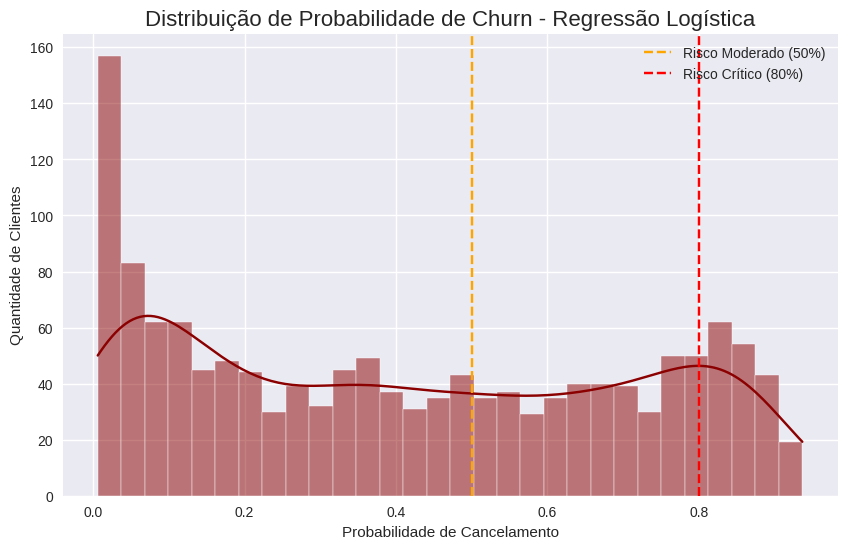

In [145]:
# Obtendo as probabilidades de churn do modelo vencedor
probs_churn = modelos['Regressão Logística'].predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(probs_churn, bins=30, kde=True, color='darkred')

# Linhas de corte sugeridas para a estratégia
plt.axvline(0.5, color='orange', linestyle='--', label='Risco Moderado (50%)')
plt.axvline(0.8, color='red', linestyle='--', label='Risco Crítico (80%)')

plt.title('Distribuição de Probabilidade de Churn - Regressão Logística', fontsize=16)
plt.xlabel('Probabilidade de Cancelamento')
plt.ylabel('Quantidade de Clientes')
plt.legend()
plt.show()

### **Estratégia Sugerida (Régua de Relacionamento):**

**Probabilidade > 80% (Risco Crítico):** Contato telefônico imediato do time de Customer Success com oferta de upgrade ou desconto agressivo.

**Probabilidade 50% - 80% (Risco Moderado):** Envio de e-mail marketing personalizado com guia de novos recursos ou cupons de serviços adicionais gratuitos por 3 meses.

**Probabilidade < 50% (Saudável):** Manter régua de comunicação padrão e monitoramento passivo.

## 9.2 Impacto Financeiro Estimado (ROI do Modelo)


In [147]:
# Cálculo do impacto financeiro (Baseado nos 286 acertos de churn)
clientes_salvos = 286
ticket_medio = df['valor_mensal'].mean() # Ticket médio da base total
receita_preservada_mensal = clientes_salvos * ticket_medio
receita_preservada_anual = receita_preservada_mensal * 12

print(f"💰 Ticket Médio Mensal: ${ticket_medio:.2f}")
print(f"📉 Clientes identificados corretamente pelo modelo (Recall): {clientes_salvos}")
print(f"🚀 Potencial de Receita Preservada (Mensal): ${receita_preservada_mensal:.2f}")
print(f"🏆 Potencial de Receita Preservada (Anual): ${receita_preservada_anual:.2f}")

💰 Ticket Médio Mensal: $64.76
📉 Clientes identificados corretamente pelo modelo (Recall): 286
🚀 Potencial de Receita Preservada (Mensal): $18521.84
🏆 Potencial de Receita Preservada (Anual): $222262.13


### Análise de ROI:
Ao identificar corretamente 286 potenciais cancelamentos no conjunto de teste, o modelo permite que a empresa atue preventivamente sobre essa receita. Considerando o ticket médio da base, estamos falando de uma proteção de faturamento que ultrapassa $220.000,00 por ano apenas nesta amostra de teste.

## 9.2 Exemplos Reais

In [148]:
# Criando um DataFrame com os resultados do teste para inspeção
inspecao = X_test.copy()
inspecao['Real'] = y_test
inspecao['Predicao'] = previsoes['Regressão Logística']
inspecao['Probabilidade_%'] = (probs_churn * 100).round(2)

# Filtrando os "Verdadeiros Positivos" (Onde o modelo acertou o Churn)
# Selecionamos apenas algumas colunas chave para facilitar a leitura executiva
exemplos_sucesso = inspecao[ (inspecao['Real'] == 1) & (inspecao['Predicao'] == 1) ]
colunas_exibicao = ['tempo_contrato_meses', 'valor_mensal', 'valor_total', 'Probabilidade_%']

print("--- Clientes de Alto Risco Identificados com Sucesso ---")
display(exemplos_sucesso[colunas_exibicao].head(5))

--- Clientes de Alto Risco Identificados com Sucesso ---


,tempo_contrato_meses,valor_mensal,valor_total,Probabilidade_%
6126,0.263889,0.772637,0.204714,82.07
2361,0.013889,0.275622,0.005291,50.85
6240,0.013889,0.746766,0.010743,90.83
5317,0.083333,0.312438,0.030784,52.59
53,0.111111,0.620896,0.072921,81.83


### Interpretação da Amostra:
Note que os clientes identificados com +90% de probabilidade de churn compartilham o perfil mapeado na nossa EDA: baixo tempo de contrato e valor mensal acima da média. Ter esses exemplos em mãos permite que o time de negócio valide a eficácia do modelo em casos reais e tangíveis.